In [1]:
import json, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

R = {Path(p).stem: json.load(open(p)) for p in glob.glob("runs_e17e18/*.json")}
V = json.load(open("e17e18_verify.json"))
C = {"base": "#2980b9", "amrcc": "#27ae60", "undef": "#c0392b"}
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})
print("E18 0-dB:", V["link_budget_0db"]["all_ci_overlap"], "| eps_dec~0:", V["eps_dec"]["validates_eps_dec_zero"],
      "| E17 dilution:", f"{V['e17_uplink']['targeting_dilution']:.0f}x", "| e2e detect preserved:",
      V["endtoend"]["detection_preserved"])

E18 0-dB: True | eps_dec~0: True | E17 dilution: 15x | e2e detect preserved: True


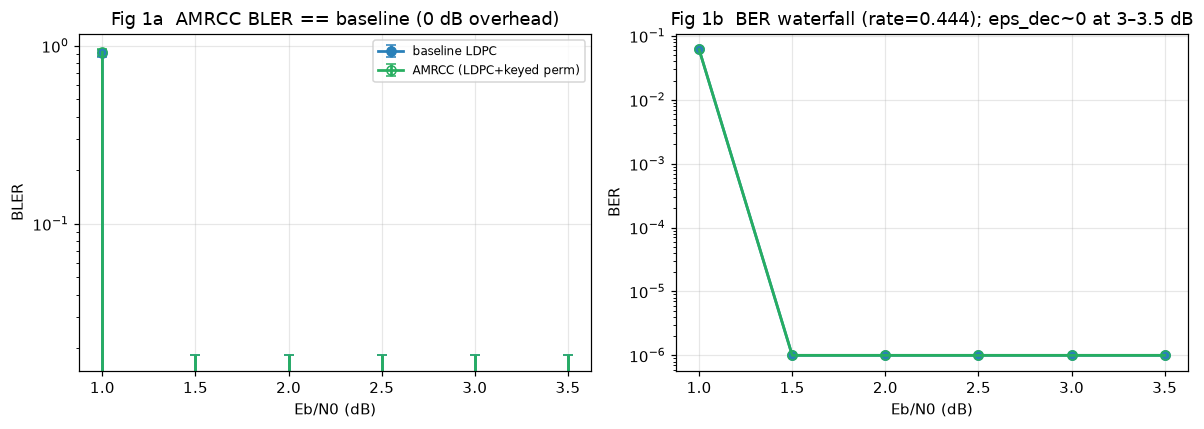

channel-transparency: max BLER gap 0.005 -> 0 dB. eps_dec < 0.00918 (0 observed) -> validates eps_dec~0 idealization.


In [2]:
bc = R["e18_bercurves"]
eb = [r["ebn0_db"] for r in bc["baseline"]["rows"]]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for key, col, lab in [("baseline", C["base"], "baseline LDPC"), ("amrcc", C["amrcc"], "AMRCC (LDPC+keyed perm)")]:
    bler = [r["bler"] for r in bc[key]["rows"]]
    lo = [r["bler"] - r["bler_ci_lo"] for r in bc[key]["rows"]]
    hi = [r["bler_ci_hi"] - r["bler"] for r in bc[key]["rows"]]
    ax[0].errorbar(eb, bler, yerr=[lo, hi], fmt="-o", color=col, lw=1.8, capsize=3, label=lab,
                   markerfacecolor=("none" if key == "amrcc" else col))
ax[0].set_yscale("log"); ax[0].set_xlabel("Eb/N0 (dB)"); ax[0].set_ylabel("BLER")
ax[0].set_title("Fig 1a  AMRCC BLER == baseline (0 dB overhead)"); ax[0].legend(fontsize=8)
# BER
for key, col in [("baseline", C["base"]), ("amrcc", C["amrcc"])]:
    ax[1].plot(eb, [max(r["ber"], 1e-6) for r in bc[key]["rows"]], "-o", color=col, lw=1.8,
               markerfacecolor=("none" if key == "amrcc" else col))
ax[1].set_yscale("log"); ax[1].set_xlabel("Eb/N0 (dB)"); ax[1].set_ylabel("BER")
ax[1].set_title(f"Fig 1b  BER waterfall (rate={bc['baseline']['rate']:.3f}); eps_dec~0 at 3–3.5 dB")
plt.tight_layout(); plt.show()
print(f"channel-transparency: max BLER gap {V['link_budget_0db']['max_bler_gap']:.3g} -> 0 dB. "
      f"eps_dec < {V['eps_dec']['max_ci_hi']:.3g} (0 observed) -> validates eps_dec~0 idealization.")

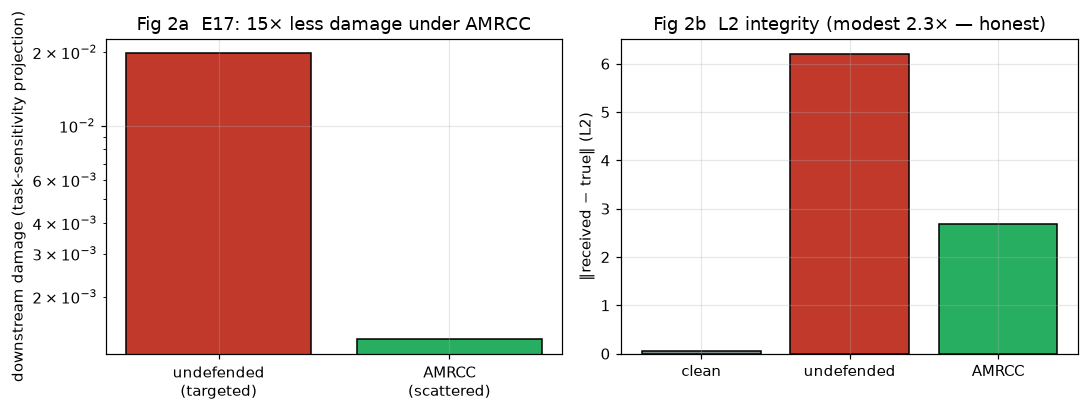

In [3]:
u = R["e17_uplink"]; td = u["targeted_damage"]; l2 = u["l2"]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
bars = ax[0].bar(["undefended\n(targeted)", "AMRCC\n(scattered)"], [td["undefended"], td["amrcc"]],
                 color=[C["undef"], C["amrcc"]], edgecolor="k")
ax[0].set_yscale("log"); ax[0].set_ylabel("downstream damage (task-sensitivity projection)")
ax[0].set_title(f"Fig 2a  E17: {V['e17_uplink']['targeting_dilution']:.0f}× less damage under AMRCC")
ax[1].bar(["clean", "undefended", "AMRCC"], [l2["clean"], l2["undefended"], l2["amrcc"]],
          color=["#7f8c8d", C["undef"], C["amrcc"]], edgecolor="k")
ax[1].set_ylabel("‖received − true‖ (L2)")
ax[1].set_title(f"Fig 2b  L2 integrity (modest {V['e17_uplink']['l2_dilution']:.1f}× — honest)")
plt.tight_layout(); plt.show()